# Reionised bubbles around primordial galaxies

## Introduction

This is the first ipython notebook to be followed alongside the background problems in the exercise sheet. The following code only serves as a starting point, feel free to adjust it as you see fit.

### Software requirements

### Option A: Setting up your own python environment

I highly recommend using an [Anaconda environment](https://docs.conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html) to manage your python installation. Having installed [Anaconda](https://docs.conda.io/projects/conda/en/latest/user-guide/install/index.html#), you can create a new environment from the command line by going into this repository's `auxiliary` directory and using the `bubble3.yml` file listing the necessary modules:
```
cd reionised-bubbles-tutorial/auxiliary
conda env create -f bubble3.yml
conda activate bubble3
```
Then, the following commands first confirm which `pip` installation manager is active, among which should be the one from your new Anaconda environment if it has been properly activated, and install the standalone `spectres` module (NB: you may have to change the directory depending on where `anaconda` is installed):
```
which pip3 # check which pip installation manager is active
pip3 install spectres
```
Then, you can start up a Jupyter notebook instance with (again checking if it correctly uses your conda environment):
```
which jupyter
jupyter notebook
```

### Option B: Installing requirements in a pre-existing python environment

If you have an existing python environment you would like to use for running the Jupyter notebooks, you can install the necessary dependencies with the `pip` installation manager by going into this repository's `auxiliary` directory and using the `requirements.txt` file listing the required modules (including the standalone `spectres` module):
```
cd reionised-bubbles-tutorial/auxiliary
which pip3 # check which pip installation manager is active
pip3 install -r requirements.txt
```

In [1]:
# Load necessary packages
import numpy as np

import matplotlib
%matplotlib inline
print("Matplotlib", matplotlib.__version__, "(backend: " + matplotlib.get_backend() + ')')
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style("ticks")

# Load matplotlib style file
plt.style.use("../auxiliary/bubble.mplstyle")

pformat = ".png"

# Import astropy cosmology, given H0 and Omega_matter (Planck Collaboration 2020)
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315, Ob0=0.02237/0.674**2, Tcmb0=2.726)

# Physical constants and unit conversions
from astropy.constants import h, c, sigma_sb, L_sun
from astropy import units

Matplotlib 3.10.8 (backend: inline)


## Exercises: calculation templates

In [ ]:
# Problem 1.1: Rydberg constant
E_n = lambda n: -13.6/n**2 # energy of level n in eV

R_H = (your_calculation_involving(E_n) * units.eV).to("1/Angstrom").value # Rydberg constant in 1/Angstrom

print("The Rydberg constant is R_H = {:.5f} Å^-1".format(R_H))

In [ ]:
# Problem 1.1: Rydberg constant

from astropy import units
from astropy import constants as const

E_n = lambda n: -13.6/n**2 # energy of level n in eV

R_H = ((E_n(2) - E_n(1)) / (1 - 1/4) * units.eV / (const.h * const.c)).to("1/Angstrom").value

print("The Rydberg constant is R_H = {:.5f} Å^-1".format(R_H))

The Rydberg constant is R_H = 0.00110 Å^-1


In [ ]:
# Problem 1.2a-b: wavelengths of Lyα, Hα, Paα and their redshift coverage by JWST/NIRSpec
fig, ax = plt.subplots(figsize=(8.27/2, 8.27/2))
z = np.linspace(0, 20, 100)

wavelength_coverage_PRISM = [np.nan, np.nan]
wavelength_coverage_G235M = [np.nan, np.nan]

ax.fill_between(wavelength_coverage_PRISM, y1=0, y2=1, transform=ax.get_xaxis_transform(), edgecolor="None", facecolor="grey", alpha=0.2, label="PRISM coverage")
ax.fill_between(wavelength_coverage_G235M, y1=0, y2=1, transform=ax.get_xaxis_transform(), edgecolor="None", facecolor="b", alpha=0.2, label="G235M coverage")

line_labels = {"Lyα": r"$\mathrm{Ly\alpha}$", "Hα": r"$\mathrm{H\alpha}$", "Paα": r"$\mathrm{Pa\alpha}$"}
print("The wavelengths of hydrogen electronic transitions:")
for i, line_label in enumerate(line_labels):
    n = i + 1
    wl = 1.0 / (R_H) * np.nan
    print("{:d} -> {:d}: {:.2f} Å".format(n+1, n, wl))
    if n == 1: wl_Lya = wl
    
    ax.plot(z * wl * 1e-4, z, alpha=0.8, label=line_label)

ax.set_xlabel(r"Observed wavelength $\lambda_\mathrm{obs} \, (\mathrm{\mu m})$")
ax.set_ylabel(r"Redshift $z$")

ax.set_xlim(0.0, 8.5)
ax.set_ylim(0, 20)

ax.legend(frameon=False)

plt.show()

Hydrogen wavelengths and JWST/NIRSpec redshift coverage:
Lyα (2->1): 1215.53 Å
   PRISM : z = 3.94 to 42.60
   G235M : z = 12.66 to 24.26
Hα  (3->2): 6563.87 Å
   PRISM : z = -0.09 to 7.07
   G235M : z = 1.53 to 3.68
Paα (4->3): 18753.91 Å
   PRISM : z = -0.68 to 1.83
   G235M : z = -0.11 to 0.64

He II comparison:
Lyα: He II wavelength = 303.88 Å = 303.88 Å (i.e. 4x shorter than H)
Hα : He II wavelength = 1640.97 Å = 1640.97 Å (i.e. 4x shorter than H)
Paα: He II wavelength = 4688.48 Å = 4688.48 Å (i.e. 4x shorter than H)


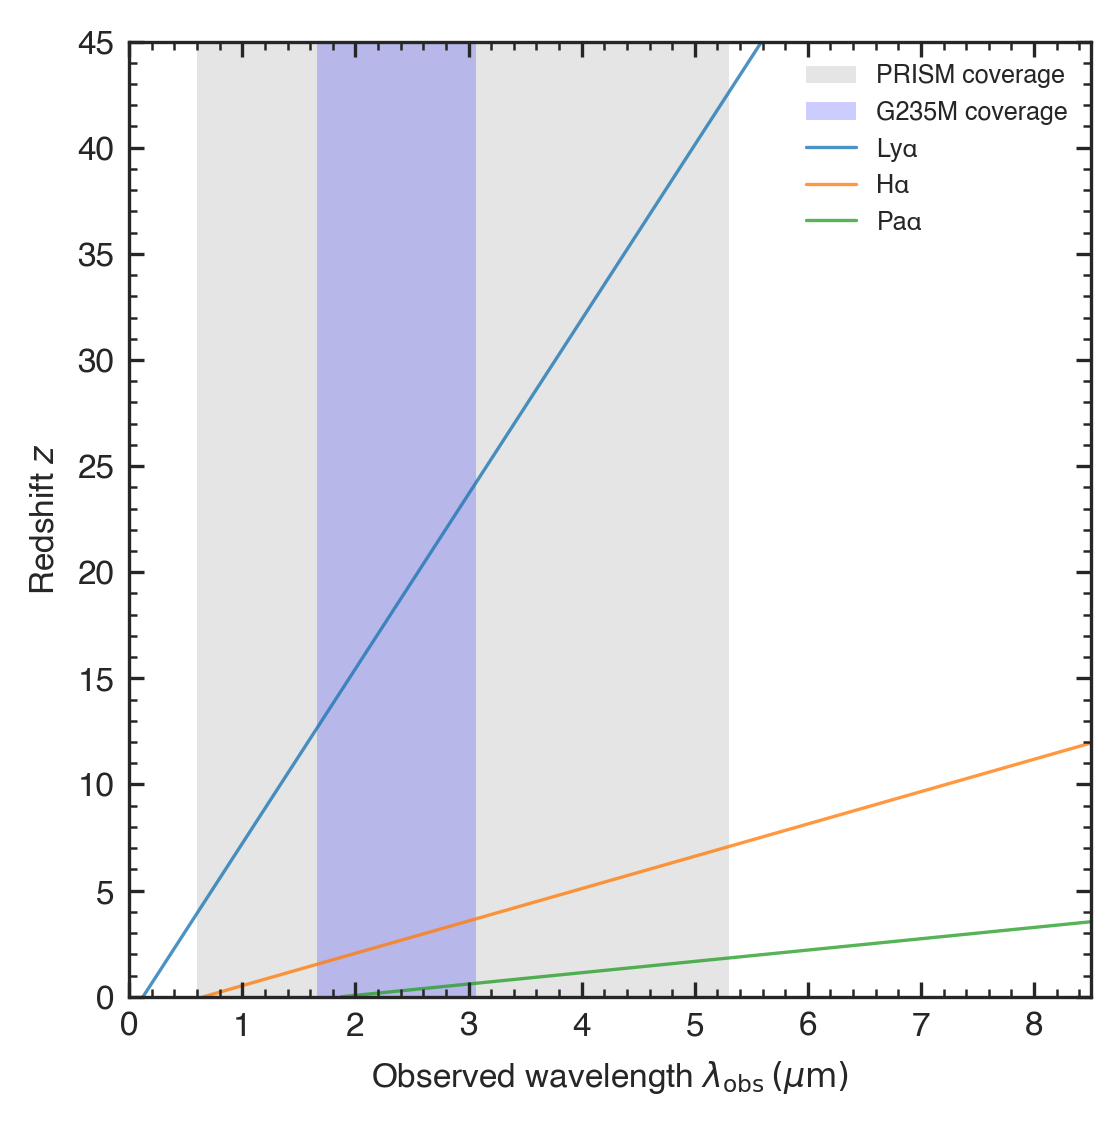

In [4]:
# Problem 1.2a-b-c: wavelengths of Lyα, Hα, Paα and their redshift coverage by JWST/NIRSpec

fig, ax = plt.subplots(figsize=(8.27/2, 8.27/2))
z = np.linspace(0, 45, 1000)

# NIRSpec wavelength coverage in micron
wavelength_coverage_PRISM = [0.60, 5.30]
wavelength_coverage_G235M = [1.66, 3.07]

ax.fill_between(wavelength_coverage_PRISM, y1=0, y2=1, transform=ax.get_xaxis_transform(),
                edgecolor="None", facecolor="grey", alpha=0.2, label="PRISM coverage")
ax.fill_between(wavelength_coverage_G235M, y1=0, y2=1, transform=ax.get_xaxis_transform(),
                edgecolor="None", facecolor="b", alpha=0.2, label="G235M coverage")

line_labels = {"Lyα": 1, "Hα": 2, "Paα": 3}

print("Hydrogen wavelengths and JWST/NIRSpec redshift coverage:")
for label, n in line_labels.items():
    # (n+1) -> n transition
    wl = 1.0 / (R_H * (1/n**2 - 1/(n+1)**2))   # Angstrom
    wl_um = wl * 1e-4                          # micron

    z_prism_min = wavelength_coverage_PRISM[0] / wl_um - 1
    z_prism_max = wavelength_coverage_PRISM[1] / wl_um - 1
    z_g235m_min = wavelength_coverage_G235M[0] / wl_um - 1
    z_g235m_max = wavelength_coverage_G235M[1] / wl_um - 1

    print(f"{label:3s} ({n+1}->{n}): {wl:.2f} Å")
    print(f"   PRISM : z = {z_prism_min:.2f} to {z_prism_max:.2f}")
    print(f"   G235M : z = {z_g235m_min:.2f} to {z_g235m_max:.2f}")

    # observed wavelength track
    ax.plot((1 + z) * wl_um, z, alpha=0.8, label=label)

print("\nHe II comparison:")
for label, n in line_labels.items():
    wl_H  = 1.0 / (R_H * (1/n**2 - 1/(n+1)**2))     # hydrogen, Z=1
    wl_He = 1.0 / ((4*R_H) * (1/n**2 - 1/(n+1)**2)) # He II, Z=2 => Z^2=4
    print(f"{label:3s}: He II wavelength = {wl_He:.2f} Å = {wl_H/4:.2f} Å (i.e. 4x shorter than H)")

ax.set_xlabel(r"Observed wavelength $\lambda_\mathrm{obs}\,(\mu\mathrm{m})$")
ax.set_ylabel(r"Redshift $z$")
ax.set_xlim(0.0, 8.5)
ax.set_ylim(0, 45)
ax.legend(frameon=False)

plt.show()

In [5]:
# Problem 1.2c: compare hydrogen and He II wavelengths

line_labels = {"Lyα": 1, "Hα": 2, "Paα": 3}

print("Comparison between H and He II wavelengths:")
for label, n in line_labels.items():
    wl_H  = 1.0 / (R_H * (1/n**2 - 1/(n+1)**2))          # Angstrom, hydrogen (Z=1)
    wl_HeII = 1.0 / ((2**2) * R_H * (1/n**2 - 1/(n+1)**2))  # Angstrom, He II (Z=2)

    print(f"{label:3s}:")
    print(f"   H    = {wl_H:.2f} Å")
    print(f"   HeII = {wl_HeII:.2f} Å")
    print(f"   HeII/H = {wl_HeII/wl_H:.2f}")

Comparison between H and He II wavelengths:
Lyα:
   H    = 1215.53 Å
   HeII = 303.88 Å
   HeII/H = 0.25
Hα :
   H    = 6563.87 Å
   HeII = 1640.97 Å
   HeII/H = 0.25
Paα:
   H    = 18753.91 Å
   HeII = 4688.48 Å
   HeII/H = 0.25


In [ ]:
# Problem 1.4a: Strömgren radius of H II region
temperatures = np.arange(1e4, 4e4, 1e4) # electron temperatures in K
dN_ion_dt = np.nan # ionizing photon rate in s^-1
n_H = np.nan # hydrogen number density in cm^-3
alpha_rec = lambda T: this_value_will_be_returned # recombination coefficient in cm^3 s^-1

print("Strömgren radius around the star for a range of electron temperatures:")
for T in temperatures:
    R_S = (np.nan).to("pc").value # Strömgren radius in parsec
    print("For T = {:.1f} x 10^4 K, R_S = {:.2f} parsec, so the cloud would be {} bounded".format(T/1e4, R_S, "density" if 2*R_S > 4.0 else "ionisation"))

In [6]:
# Problem 1.4a: Strömgren radius of H II region
temperatures = np.arange(1e4, 4e4, 1e4) # electron temperatures in K
dN_ion_dt = 1e49 / units.s # ionizing photon rate in s^-1
n_H = 300 / units.cm**3 # hydrogen number density in cm^-3
alpha_rec = lambda T: 2.54e-13 * (T/1e4)**(-0.8) * units.cm**3 / units.s # recombination coefficient in cm^3 s^-1

print("Strömgren radius around the star for a range of electron temperatures:")
for T in temperatures:
    R_S = ((3 * dN_ion_dt) / (4 * np.pi * alpha_rec(T) * n_H**2))**(1/3)
    R_S = R_S.to("pc").value # Strömgren radius in parsec
    print("For T = {:.1f} x 10^4 K, R_S = {:.2f} parsec, so the cloud would be {} bounded".format(T/1e4, R_S, "density" if 2*R_S > 4.0 else "ionisation"))

Strömgren radius around the star for a range of electron temperatures:
For T = 1.0 x 10^4 K, R_S = 1.53 parsec, so the cloud would be ionisation bounded
For T = 2.0 x 10^4 K, R_S = 1.84 parsec, so the cloud would be ionisation bounded
For T = 3.0 x 10^4 K, R_S = 2.05 parsec, so the cloud would be density bounded


In [ ]:
# Problem 1.4b: Lyα luminosity of H II region
E_Lya = np.nan # Lyα photon energy in erg

dNdt_Lya = np.nan * dN_ion_dt # Lyα emission rate in Hz
L_Lya = combine(dNdt_Lya, E_Lya) # Lyα luminosity in erg/s
logL_Lya = int(np.log10(L_Lya))

T_star = np.nan # stellar temperature in K
R_star = (np.nan * units.R_sun) # stellar radius in cm
L_star = (sigma_sb * np.nan).to("erg/s").value # stellar luminosity in erg/s

print("The Lyα emission rate in the H II region is {:.2f} x 10^48 per second".format(dNdt_Lya/1e48))
print("This results in a luminosity of L_Lyα = {:.2f} x 10^{:d} erg/s or {:.2f} L_sun,".format(L_Lya/10**logL_Lya, logL_Lya, L_Lya/L_sun.to("erg/s").value))
print("which is {:.1f}% of the luminosity of the central star (L_* = {:.2f} L_sun)".format(L_Lya/L_star*100.0, L_star/L_sun.to("erg/s").value))

In [9]:
# Problem 1.4b: Lyα luminosity of H II region
E_Lya = (const.h * const.c / (1215.67 * units.Angstrom)).to("erg").value # Lyα photon energy in erg

dNdt_Lya = (2/3) * dN_ion_dt.value # Lyα emission rate in s^-1
L_Lya = dNdt_Lya * E_Lya # Lyα luminosity in erg/s
logL_Lya = int(np.log10(L_Lya))

T_star = 4.0e4 * units.K # stellar temperature
R_star = 10 * const.R_sun # stellar radius
L_star = (4 * np.pi * R_star**2 * const.sigma_sb * T_star**4).to("erg/s").value # stellar luminosity in erg/s

print("The Lyα emission rate in the H II region is {:.2f} x 10^48 per second".format(dNdt_Lya/1e48))
print("This results in a luminosity of L_Lyα = {:.2f} x 10^{:d} erg/s or {:.2f} L_sun,".format(L_Lya/10**logL_Lya, logL_Lya, L_Lya/const.L_sun.to("erg/s").value))
print("which is {:.1f}% of the luminosity of the central star (L_* = {:.2f} L_sun)".format(L_Lya/L_star*100.0, L_star/const.L_sun.to("erg/s").value))

The Lyα emission rate in the H II region is 6.67 x 10^48 per second
This results in a luminosity of L_Lyα = 1.09 x 10^38 erg/s or 28457.57 L_sun,
which is 12.3% of the luminosity of the central star (L_* = 230639.48 L_sun)


# Exercise 2

In [ ]:
# Problem 2.1a: cosmic expansion of an ionised bubble
z = np.nan
# Hint: use the astropy cosmology to calculate the Hubble parameter H and the age of the Universe at redshift z
print("At z = {:.1f}, the e-folding time is {:.1f},".format(z, some_function_involving(z)), end=' ')
print("while the age of the Universe is {:.1f}".format(get_age_of_Universe_at_redshift(z).to("Myr")))

In [10]:
# Problem 2.1a: cosmic expansion of an ionised bubble
z = 7.0
# Hint: use the astropy cosmology to calculate the Hubble parameter H and the age of the Universe at redshift z
print("At z = {:.1f}, the e-folding time is {:.1f},".format(z, (1 / cosmo.H(z)).to("Myr").value), end=' ')
print("while the age of the Universe is {:.1f}".format(cosmo.age(z).to("Myr").value))

At z = 7.0, the e-folding time is 1138.6, while the age of the Universe is 758.5


In [12]:
# Problem 2.1b: bubble growth without expansion or recombinations
R_ion = lambda t, f_escLyC, dN_ion_dt, n_H: ((3 * f_escLyC * dN_ion_dt * t) / (4 * np.pi * n_H))**(1/3)

In [ ]:
# Problem 2.1c: ionisations and recombinations inside an ionised bubble
dN_ion_dt_Myr = (np.nan * units.the_right_units).to("1/Myr").value # ionizing photon rate from ??? to 1/Myr
f_escLyC = np.nan # escape fraction of Lyman-continuum photons
n_H_0 = np.nan # hydrogen number density at z = 0 in cm^-3

C_HII = np.nan # clumping factor
alpha_rec_IGM = (alpha_rec(np.nan) * units.the_right_units).to("Mpc^3/Myr").value # recombination rate in Mpc^3 Myr^-1

fig, ax = plt.subplots(figsize=(8.27/2, 8.27/2))
R_ion = np.linspace(0, 1, 100)

colors1 = sns.color_palette("Set1", 9)

for z, c in zip([12, 7], colors1):
    # Mean hydrogen number density at redshift z (converted to Mpc^-3)
    n_H = scale_n_with_z(n_H_0).to("Mpc^-3").value
    ax.axhline(y=only_depends_on(n_H), linestyle='--', color=c, alpha=0.8, label=r"Ionisation ($z = {:.0f}$)".format(z))
    ax.plot(R_ion, recombinations_are_a_function_of(R_ion), color=c, alpha=0.8, label=r"Recombination ($z = {:.0f}$)".format(z))

ax.set_xlabel(r"Ionised bubble radius $R_\mathrm{ion} \, (\mathrm{pMpc})$")
ax.set_ylabel(r"Ionised volume rate of change $dR_\mathrm{ion}^3/dt \, (\mathrm{pMpc^3 \, Myr^{-1}})$")

ax.set_xlim(0.0, 1.0)
ax.set_ylim(4e-6, 0.02)

ax.set_yscale("log")

ax.legend(frameon=False)

plt.show()

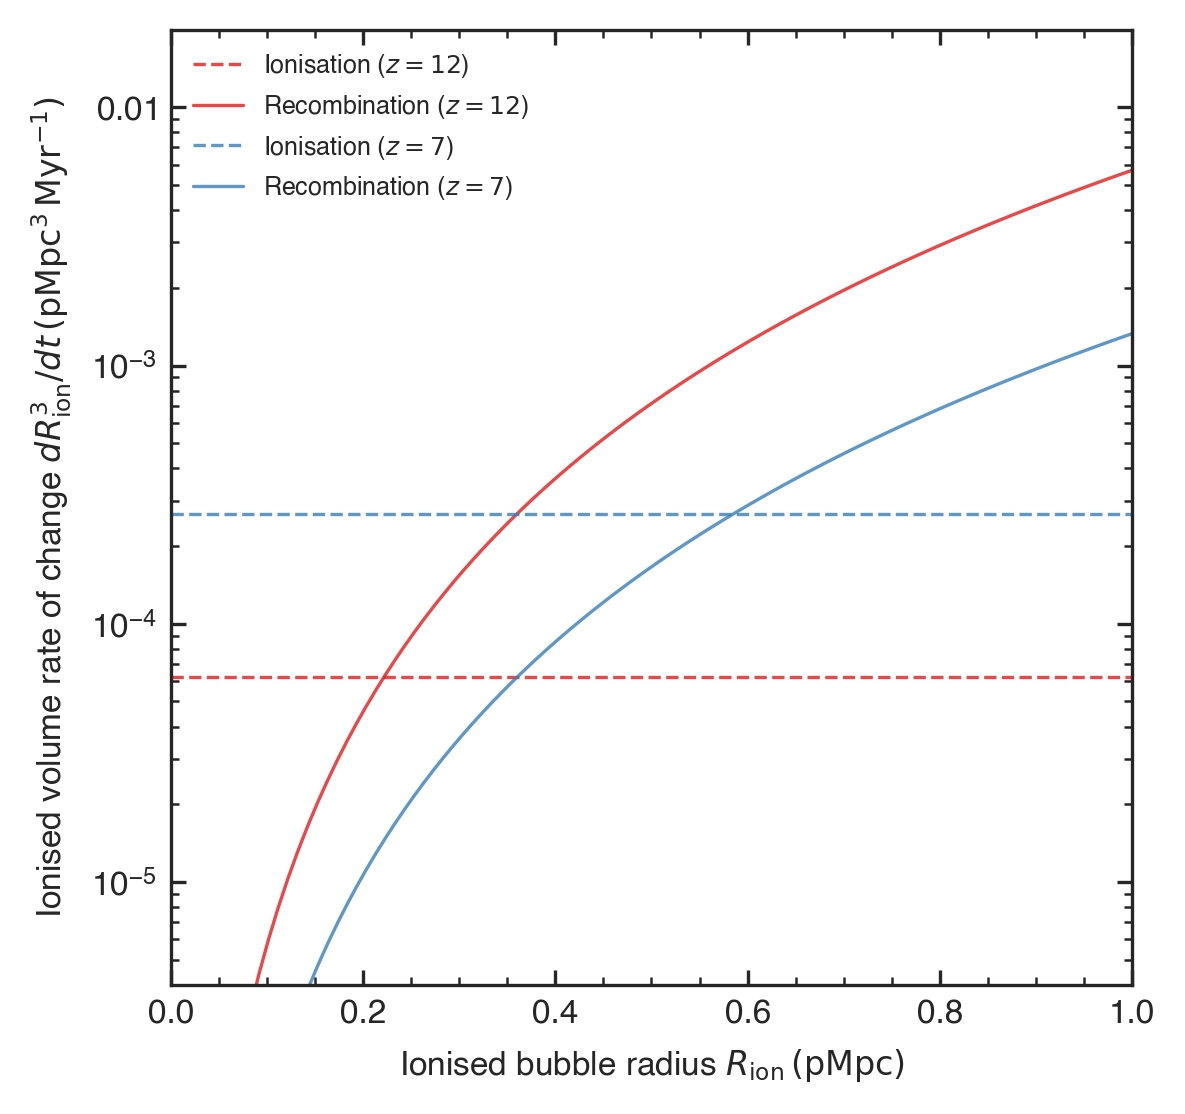

At z = 7, balance occurs at R_ion = 0.585 pMpc
At z = 12, balance occurs at R_ion = 0.222 pMpc


In [11]:
# Problem 2.1c: ionisations and recombinations inside an ionised bubble
dN_ion_dt_Myr = (1e54 / units.s).to("1/Myr").value # ionizing photon rate to 1/Myr
f_escLyC = 0.1 # escape fraction of Lyman-continuum photons
n_H_0 = 1.88e-7 / units.cm**3 # hydrogen number density at z = 0 in cm^-3

C_HII = 3.0 # clumping factor
alpha_rec_IGM = alpha_rec(2e4).to("Mpc^3/Myr").value # recombination rate in Mpc^3 Myr^-1

fig, ax = plt.subplots(figsize=(8.27/2, 8.27/2))
R_ion = np.linspace(1e-3, 1, 100)

colors1 = sns.color_palette("Set1", 9)

for z, c in zip([12, 7], colors1):
    # Mean hydrogen number density at redshift z (converted to Mpc^-3)
    n_H = (n_H_0 * (1 + z)**3).to("Mpc^-3").value
    ax.axhline(y=3 * f_escLyC * dN_ion_dt_Myr / (4 * np.pi * n_H), linestyle='--', color=c, alpha=0.8, label=r"Ionisation ($z = {:.0f}$)".format(z))
    ax.plot(R_ion, C_HII * n_H * alpha_rec_IGM * R_ion**3, color=c, alpha=0.8, label=r"Recombination ($z = {:.0f}$)".format(z))

ax.set_xlabel(r"Ionised bubble radius $R_\mathrm{ion} \, (\mathrm{pMpc})$")
ax.set_ylabel(r"Ionised volume rate of change $dR_\mathrm{ion}^3/dt \, (\mathrm{pMpc^3 \, Myr^{-1}})$")

ax.set_xlim(0.0, 1.0)
ax.set_ylim(4e-6, 0.02)

ax.set_yscale("log")

ax.legend(frameon=False)

plt.show()

for z in [7, 12]:
    n_H = (n_H_0 * (1 + z)**3).to("Mpc^-3").value
    R_bal = ((3 * f_escLyC * dN_ion_dt_Myr) / (4 * np.pi * C_HII * n_H**2 * alpha_rec_IGM))**(1/3)
    print(f"At z = {z:.0f}, balance occurs at R_ion = {R_bal:.3f} pMpc")